This project investigates material classification using RGB imagery enhanced with estimated spectral reflectance. A CNN classifier is trained on fused RGB + spectral channels, while spectral dictionary matching using SAM serves as an auxiliary constraint. This hybrid approach combines data-driven learning with physics-aware spectral priors, enabling robust classification of architectural and environmental materials.

In [565]:
%pip install torch
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [566]:
import sys
print(sys.executable)

import os
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.stats import skew, kurtosis
from tabulate import tabulate

/Users/sutku/Scripts/ML/venv/bin/python


In [567]:
path = os.getcwd()
print(path)

/Users/sutku/Scripts/ML/final


https://icvl.cs.bgu.ac.il/pages/researches/hyperspectral-imaging.html
ICVL Dataset Characteristics: 


GeoMatRGB dataset contains colored image patches for each category and the GeoMatNTxtH contains normal histograms for each category. All of the datasets are downloaded
automatically when Setup_GeoInfMatRec.m is ran.

In [568]:
import scipy.io as sio

In [569]:
import os
import cv2
import torch
import numpy as np
import scipy.io as sio
from torch.utils.data import Dataset

In [570]:
class GeoMatDataset(Dataset):
    def __init__(self, root, split="train"):
        self.rgb_root   = os.path.join(root, "data/GeomatRGB")
        self.depth_root = os.path.join(root, "data/GeomatD")
        # get classes (as folders)
        self.classes = [
            d for d in sorted(os.listdir(self.rgb_root))
            if os.path.isdir(os.path.join(self.rgb_root, d))
        ]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []

        for cls_idx in self.classes:
            label = self.class_to_idx[cls_idx]
            rgb_folder   = os.path.join(self.rgb_root, cls_idx, split)
            depth_folder = os.path.join(self.depth_root, cls_idx, split)

            # list all files inside the train/test folders
            rgb_files = sorted([f for f in os.listdir(rgb_folder) if f.endswith(".png")])
            depth_files = sorted([f for f in os.listdir(depth_folder) if f.endswith(".mat")])

            # Pair RGB and depth 1-to-1 using filenames
            for rf, df in zip(rgb_files, depth_files):
                self.samples.append((
                    os.path.join(rgb_folder, rf),
                    os.path.join(depth_folder, df),
                    self.class_to_idx[cls_idx]
                ))
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx): # accessing specific class data
        rgb_path, depth_path, label = self.samples[idx]

        rgb = cv2.imread(rgb_path)
        rgb = (cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB).astype(np.float32))/ 255
        rgb = torch.tensor(rgb).permute(2, 0, 1)

        mat = sio.loadmat(depth_path)
        nx = mat["Nx"].astype(np.float32)
        ny = mat["Ny"].astype(np.float32)
        nz = mat["Nz"].astype(np.float32)
        normals = torch.tensor(np.stack([nx, ny, nz], axis=0))
        normals = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + 1e-8) # normalize

        label = torch.tensor(label, dtype=torch.long)
        return rgb, normals, label


In [597]:
from torch.utils.data import random_split
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset

train_dataset = GeoMatDataset("", split="train")
test_dataset  = GeoMatDataset("", split="test")

labels = [lbl for _, _, lbl in test_dataset.samples]
print(Counter(labels))

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=42
)

test_idx, val_idx = next(splitter.split(np.zeros(len(labels)), labels))
test_subset = Subset(test_dataset, test_idx)
val_subset   = Subset(test_dataset, val_idx)

print("Train class dist:", sorted(Counter([labels[i] for i in test_idx])))
print("Val class dist:  ", Counter([labels[i] for i in val_idx]))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=True)

# rgb_path, depth_path, label = train_dataset.samples[0]
# print(type(label))

Counter({0: 200, 1: 200, 2: 200, 3: 200, 4: 200, 5: 200, 6: 200, 7: 200, 8: 200, 9: 200, 10: 200, 11: 200, 12: 200, 13: 200, 14: 200, 15: 200, 16: 200, 17: 200, 18: 200})
Train class dist: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Val class dist:   Counter({2: 100, 18: 100, 15: 100, 0: 100, 7: 100, 14: 100, 10: 100, 8: 100, 9: 100, 3: 100, 6: 100, 16: 100, 12: 100, 11: 100, 17: 100, 4: 100, 1: 100, 13: 100, 5: 100})


datachecking

In [572]:
def subset_class_distribution(subset, full_dataset):
    labels = [full_dataset.samples[i][2] for i in subset.indices]
    return Counter(labels)

print("Val class distribution:")
print(subset_class_distribution(val_subset, test_dataset))

print("Test class distribution:")
print(subset_class_distribution(test_subset, test_dataset))

Val class distribution:
Counter({2: 100, 18: 100, 15: 100, 0: 100, 7: 100, 14: 100, 10: 100, 8: 100, 9: 100, 3: 100, 6: 100, 16: 100, 12: 100, 11: 100, 17: 100, 4: 100, 1: 100, 13: 100, 5: 100})
Test class distribution:
Counter({8: 100, 10: 100, 0: 100, 14: 100, 1: 100, 7: 100, 18: 100, 16: 100, 2: 100, 9: 100, 12: 100, 6: 100, 3: 100, 13: 100, 17: 100, 5: 100, 11: 100, 4: 100, 15: 100})


In [573]:
root = "data"

rgb_root = os.path.join(root, "GeomatRGB")
depth_root = os.path.join(root, "GeomatD")

classes = [
            d for d in sorted(os.listdir(rgb_root))
            if os.path.isdir(os.path.join(rgb_root, d))
        ]

for cls in classes:
    rgb_train = os.path.join(rgb_root, cls, "train")
    d_train   = os.path.join(depth_root, cls, "train")

    print(cls)
    print("  RGB train folders:", len(os.listdir(rgb_train)))
    print("  Depth train folders:", len(os.listdir(d_train)))
    print()

sample = "data/GeoMatRGB/Asphalt/train"
depth = "data/GeoMatD/Asphalt/train"

print(sorted(os.listdir(sample)))
print(sorted(os.listdir(depth)))

Asphalt
  RGB train folders: 400
  Depth train folders: 400

Brick
  RGB train folders: 400
  Depth train folders: 400

Cement - Granular
  RGB train folders: 400
  Depth train folders: 400

Cement - Smooth
  RGB train folders: 400
  Depth train folders: 400

Concrete - Cast_in_Place
  RGB train folders: 400
  Depth train folders: 400

Concrete - Precast
  RGB train folders: 400
  Depth train folders: 400

Foliage
  RGB train folders: 400
  Depth train folders: 400

Grass
  RGB train folders: 400
  Depth train folders: 400

Gravel
  RGB train folders: 400
  Depth train folders: 400

Marble
  RGB train folders: 400
  Depth train folders: 400

Metal - Grills
  RGB train folders: 400
  Depth train folders: 400

Paving
  RGB train folders: 400
  Depth train folders: 400

Soil - Compact
  RGB train folders: 400
  Depth train folders: 400

Soil - Dirt and Vegetation
  RGB train folders: 400
  Depth train folders: 400

Soil - Loose
  RGB train folders: 400
  Depth train folders: 400

Soil - M

run EDA on dataset

In [574]:
import os
import cv2
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift
import random

# --- Utility Functions ---

def load_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_normals(mat_path):
    mat = sio.loadmat(mat_path)
    nx = mat["Nx"].astype(np.float32)
    ny = mat["Ny"].astype(np.float32)
    nz = mat["Nz"].astype(np.float32)
    if nx is None or ny is None or nz is None:
        raise ValueError("Missing NX/NY/NZ in mat file")
    normals = np.stack([nx, ny, nz], axis=-1)
    eps = 1e-8
    normals_unit = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + eps)
    return normals_unit

def plot_rgb_histogram(rgb):
    colors = ("red", "green", "blue")
    plt.figure(figsize=(6,4))
    for i, col in enumerate(colors):
        plt.hist(rgb[:,:,i].flatten(), bins=256, alpha=0.5, label=col)
    plt.legend(); plt.title("RGB Histogram"); plt.tight_layout()
    plt.show()

def plot_normal_distribution(normals):
    plt.figure()
    plt.hist(normals[:,:,0].flatten(), bins=100, alpha=0.5, label="NX")
    plt.hist(normals[:,:,1].flatten(), bins=100, alpha=0.5, label="NY")
    plt.hist(normals[:,:,2].flatten(), bins=20, alpha=0.5, label="NZ")
    plt.legend(); plt.title("Normal Vector Component Distribution")
    plt.xlim(-0.025, 0.025)
    plt.show()

def fft_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    f = fft2(gray)
    fshift = fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)
    return magnitude

def compare_fft(rgb, normals):
    rgb_fft = fft_features(rgb)
    # nz_fft = fft_features(normals)  # choose NZ as geometry proxy
    f = fft2(normals)
    nz_fft = fftshift(f).astype(np.float32)
    nz_fft_mag = np.log(np.abs(nz_fft) + 1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(rgb_fft, cmap="gray"); plt.title("RGB FFT Magnitude")
    plt.subplot(1,2,2); plt.imshow(nz_fft_mag, cmap="gray"); plt.title("Normal NZ FFT Mag")
    plt.tight_layout(); plt.show()

# --- Random Sample Visualizer ---

def visualize_random_sample(rgb_folder, depth_folder):
    rgb_files = [f for f in os.listdir(rgb_folder) if f.endswith(".png")]
    depth_files = [f for f in os.listdir(depth_folder) if f.endswith(".mat")]

    idx = random.randint(0, len(rgb_files) - 1)

    rgb_path = os.path.join(rgb_folder, rgb_files[idx])
    depth_path = os.path.join(depth_folder, depth_files[idx])
     
    rgb = load_rgb(rgb_path)
    normals = load_normals(depth_path)

    plot_rgb_histogram(rgb)
    plot_normal_distribution(normals)
    compare_fft(rgb, normals[:,:,2])
    
    # norm = normals / 0.0001
    vis = (normals/0.01 + 1.0) * 0.5   # → [0,1]
    vis = (vis * 255).astype(np.uint8)
    
    plt.figure(figsize=(8,4))
    # min = np.min(normals)
    # max = np.max(normals)
    plt.subplot(1,2,1); plt.imshow(rgb); plt.title("RGB Sample")
    plt.subplot(1,2,2); plt.imshow(vis); plt.title("Normals (visualized)")
    plt.tight_layout(); plt.show()


# --- Per-Class Statistics ---

def compute_class_means(class_rgb_folder, class_depth_folder, n_samples=5):
    rgb_files = sorted([f for f in os.listdir(class_rgb_folder) if f.endswith(".png")])
    depth_files = sorted([f for f in os.listdir(class_depth_folder) if f.endswith(".mat")])

    chosen = random.sample(range(len(rgb_files)), min(n_samples, len(rgb_files)))
    
    rgb_sum = None
    normal_sum = None

    for idx in chosen:
        rgb = load_rgb(os.path.join(class_rgb_folder, rgb_files[idx]))
        normals = load_normals(os.path.join(class_depth_folder, depth_files[idx]))

        if rgb_sum is None:
            rgb_sum = rgb.astype(float)
            normal_sum = normals.astype(float)
        else:
            rgb_sum += rgb
            normal_sum += normals

    rgb_mean = (rgb_sum / len(chosen)).astype(np.uint8)
    normals_mean = normal_sum / len(chosen)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(rgb_mean); plt.title("Class Mean RGB")
    plt.subplot(1,2,2); plt.imshow((normals_mean+1)/2); plt.title("Class Mean Normals")
    plt.tight_layout(); plt.show()

# Usage example (fill in your paths):
# visualize_random_sample("path/to/rgb", "path/to/normals")
# compute_class_means("path/to/class/rgb", "path/to/class/normals")


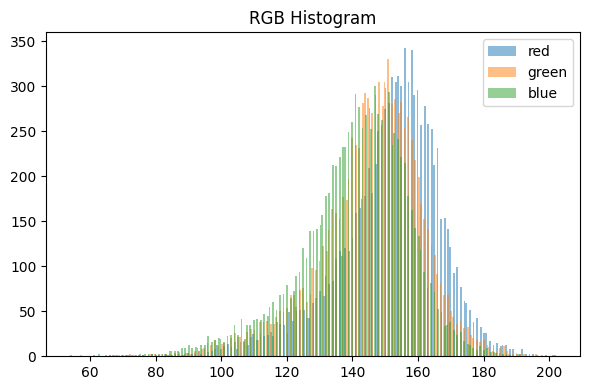

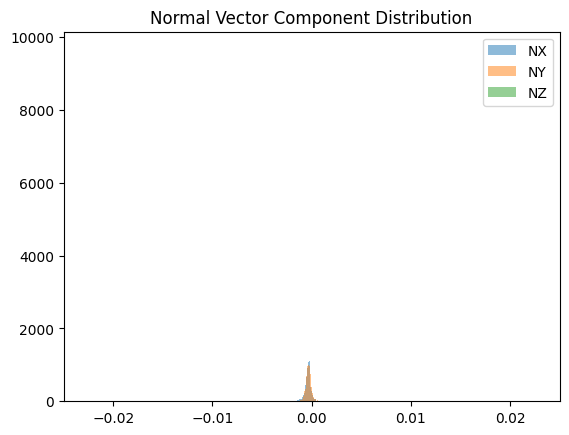

/var/folders/sj/ndc3yh8s1yxc4npz15m9pyrh0000gn/T/ipykernel_38874/3759092624.py:55: ComplexWarning: Casting complex values to real discards the imaginary part
  nz_fft = fftshift(f).astype(np.float32)


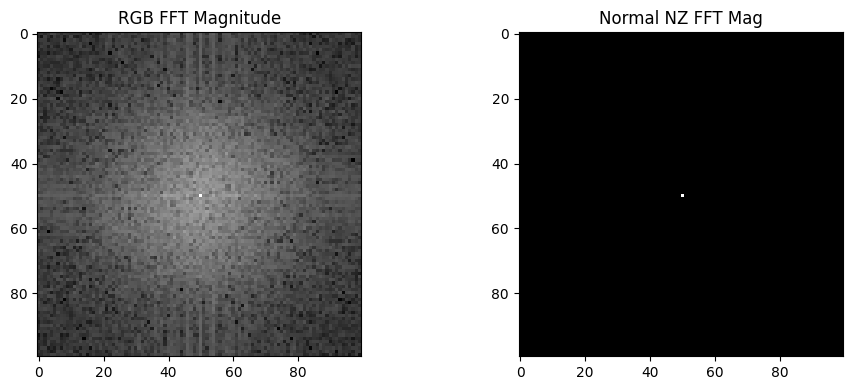

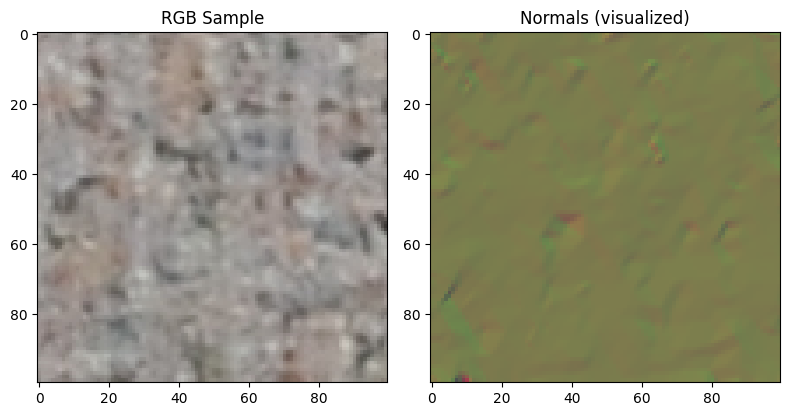

In [575]:
sample = "data/GeoMatRGB/Stone - Granular/Test"
depth = "data/GeoMatD/Stone - Granular/Test"
visualize_random_sample(sample, depth)

            nrm_low   nrm_mid  nrm_high  roughness
mean_r    -0.133643 -0.138203 -0.137041  -0.119169
mean_g    -0.042078 -0.050763 -0.047628  -0.040560
mean_b    -0.106950 -0.114689 -0.102997  -0.089832
var_r      0.224454  0.231913  0.229457   0.200056
var_g      0.240156  0.247804  0.246910   0.216888
var_b      0.306762  0.314362  0.312374   0.277558
luma_mean -0.074724 -0.082904 -0.079208  -0.068286
mean_nz   -0.916602 -0.938869 -0.938187  -0.975952
var_nx     0.900993  0.911973  0.954870   0.989880
var_ny     0.931021  0.946287  0.953288   0.990612
var_nz     0.891621  0.886957  0.884908   0.917983
roughness  0.925987  0.938925  0.963476   1.000000
rgb_low    0.260440  0.256888  0.273748   0.239893
rgb_mid    0.227550  0.243118  0.215605   0.186102
rgb_high   0.157944  0.186341  0.137858   0.116644
nrm_low    1.000000  0.987296  0.961396   0.925987
nrm_mid    0.987296  1.000000  0.972010   0.938925
nrm_high   0.961396  0.972010  1.000000   0.963476


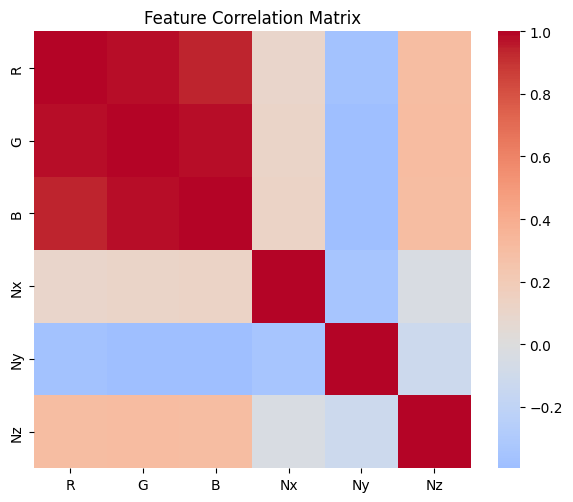

In [576]:

def rgb_features(rgb):
    rgb = rgb.astype(np.float32) / 255.0
    return {
        "mean_r": rgb[:,:,0].mean(),
        "mean_g": rgb[:,:,1].mean(),
        "mean_b": rgb[:,:,2].mean(),
        "var_r":  rgb[:,:,0].var(),
        "var_g":  rgb[:,:,1].var(),
        "var_b":  rgb[:,:,2].var(),
        "luma_mean": (0.2126*rgb[:,:,0] +
                      0.7152*rgb[:,:,1] +
                      0.0722*rgb[:,:,2]).mean()
    }
    
def normal_features(normals):
    nx, ny, nz = normals[:,:,0], normals[:,:,1], normals[:,:,2]

    return {
        "mean_nz": nz.mean(),
        "var_nx": nx.var(),
        "var_ny": ny.var(),
        "var_nz": nz.var(),
        "roughness": np.var(normals, axis=(0,1)).mean(),
    }
    
def fft_band_energy(img, low=0.1, high=0.4):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    F = np.abs(fftshift(fft2(gray)))

    h, w = F.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    radius = np.sqrt((X-cx)**2 + (Y-cy)**2) / np.sqrt(cx**2 + cy**2)

    low_energy  = F[radius < low].mean()
    mid_energy  = F[(radius >= low) & (radius < high)].mean()
    high_energy = F[radius >= high].mean()

    return low_energy, mid_energy, high_energy

def normal_fft_energy(normals):
    nz = normals[:,:,2].astype(np.float32)
    F = np.abs(fftshift(fft2(nz)))
    h, w = F.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    radius = np.sqrt((X-cx)**2 + (Y-cy)**2) / np.sqrt(cx**2 + cy**2)

    return (
        F[radius < 0.1].mean(),
        F[(radius >= 0.1) & (radius < 0.4)].mean(),
        F[radius >= 0.4].mean()
    )
    
def build_feature_matrix(rgb, normals):
    H, W, _ = rgb.shape
    rgb_f = rgb.reshape(-1, 3).astype(np.float32)
    normals_f = normals.reshape(-1, 3)

    features = np.concatenate([rgb_f, normals_f], axis=1)
    # shape: [N_pixels, 6]
    return features

def compute_corr_matrix(features):
    return np.corrcoef(features, rowvar=False)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_corr_matrix(corr):
    labels = ["R", "G", "B", "Nx", "Ny", "Nz"]
    plt.figure(figsize=(6,5))
    sns.heatmap(
        corr, 
        xticklabels=labels,
        yticklabels=labels,
        cmap="coolwarm",
        center=0,
        square=True
    )
    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

import pandas as pd

rows = []
for rgb_path, normal_path, label in train_dataset.samples:
    rgb = load_rgb(rgb_path)
    normals = load_normals(normal_path)

    rf = rgb_features(rgb)
    nf = normal_features(normals)

    rgb_fft = fft_band_energy(rgb)
    nrm_fft = normal_fft_energy(normals)

    row = {**rf, **nf,
           "rgb_low": rgb_fft[0],
           "rgb_mid": rgb_fft[1],
           "rgb_high": rgb_fft[2],
           "nrm_low": nrm_fft[0],
           "nrm_mid": nrm_fft[1],
           "nrm_high": nrm_fft[2]}
    rows.append(row)

df = pd.DataFrame(rows)

corr = df.corr(method="pearson")
print(corr[[
    "nrm_low", "nrm_mid", "nrm_high", "roughness"
]])

# sample = "data/GeoMatRGB/Stone - Granular/Test/202_014_MLB_1880_100x100_1_00001.png"
# depth = "data/GeoMatD/Stone - Granular/Test/202_014_MLB_1880_100x100_1_00001.mat"
features = build_feature_matrix(rgb, normals)
corr = compute_corr_matrix(features)
plot_corr_matrix(corr)
  
# gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
# rgb_F = np.abs(fftshift(fft2(gray))) 
# h, w = rgb_F.shape
# print(h)
# print(w)
# nz = normals[:,:,2].astype(np.float32)
# nrm_F = np.abs(fftshift(fft2(nz)))
# features = np.concatenate([rgb_F, nrm_F], axis=1)
# corr = compute_corr_matrix(features)
# plot_corr_matrix(corr)

Pixel-space RGB is dominated by illumination and low-level appearance coupling
Frequency bands encode geometry and texture; Color correlations are largely destroyed

for normal fft
How rough, structured, or smooth the surface geometry is — independent of lighting or color
Geometry has spatial coherence, Surface smoothness and curvature dominate, Structure emerges across frequencies

This analysis indicates that hyperspectral bands often have strong redundancy; each image shows strong correlations but throughout different wavelength ranges. This suggests that adjacent wavelengths are almost linear combinations of each other. While this would typically indcate the usefullness of PCA, because the goal is to reconstruct the whole spectrum, it will not be used

Use Mean Squared Error (MSE) and Spectral Angle Mapper (SAM) to penalize both magnitude and shape differences

https://medium.com/analytics-vidhya/conversion-of-rgb-images-to-hyperspectral-using-deep-learning-f3dff0a1d60a

['rgb_low', 'rgb_mid', 'rgb_high', 'nrm_low', 'nrm_mid', 'nrm_high', 'class']


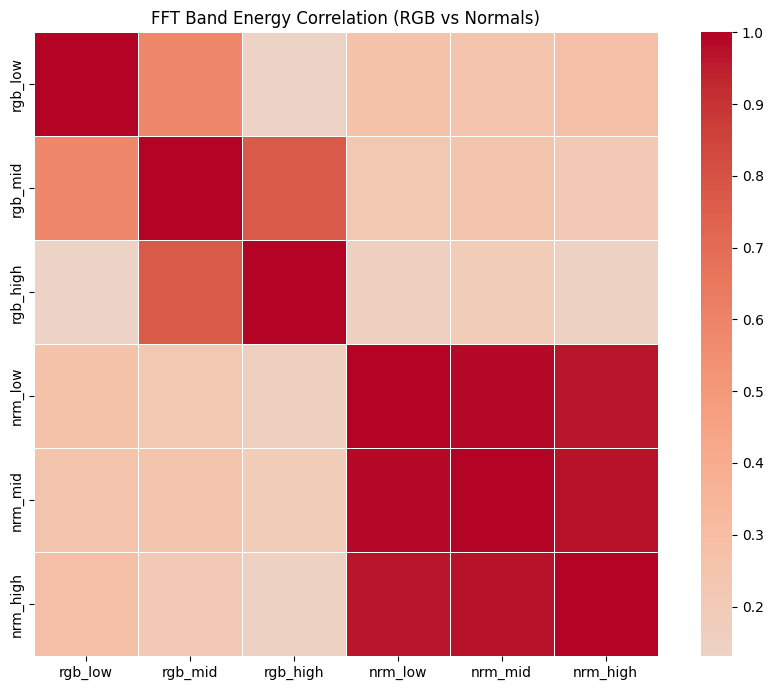

In [577]:
def rgb_stats(rgb):
    rgb = rgb.astype(np.float32) / 255.0
    luma = (
        0.2126 * rgb[:,:,0] +
        0.7152 * rgb[:,:,1] +
        0.0722 * rgb[:,:,2]
    )
    return {
        "rgb_mean": rgb.mean(),
        "rgb_var":  rgb.var(),
        "luma_mean": luma.mean(),
        "luma_var":  luma.var()
    }

def normal_stats(normals):
    nx, ny, nz = normals[:,:,0], normals[:,:,1], normals[:,:,2]
    mag = np.sqrt(nx**2 + ny**2 + nz**2)

    return {
        "nz_mean": nz.mean(),
        "nz_var":  nz.var(),
        "normal_mag_mean": mag.mean(),
        "normal_roughness": np.var(normals, axis=(0,1)).mean()
    }
    
def radial_fft_band_energy(img, bands=(0.1, 0.4)):
    F = np.abs(fftshift(fft2(img)))
    h, w = F.shape
    cy, cx = h // 2, w // 2

    Y, X = np.ogrid[:h, :w]
    radius = np.sqrt((X-cx)**2 + (Y-cy)**2)
    radius /= radius.max()

    low, mid = bands

    return {
        "low_freq":  F[radius < low].mean(),
        "mid_freq":  F[(radius >= low) & (radius < mid)].mean(),
        "high_freq": F[radius >= mid].mean()
    }

def rgb_fft_features(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    return {f"rgb_{k}": v for k, v in radial_fft_band_energy(gray).items()}

def normal_fft_features(normals):
    nz = normals[:,:,2].astype(np.float32)
    return {f"nrm_{k}": v for k, v in radial_fft_band_energy(nz).items()}

import pandas as pd

rows = []
for rgb_path, normal_path, label in train_dataset.samples:
    rgb = load_rgb(rgb_path)
    normals = load_normals(normal_path)

    rf = rgb_features(rgb)
    nf = normal_features(normals)

    rgb_fft = fft_band_energy(rgb)
    nrm_fft = normal_fft_energy(normals)

    row = {
        "rgb_low": rgb_fft[0],
        "rgb_mid": rgb_fft[1],
        "rgb_high": rgb_fft[2],
        "nrm_low": nrm_fft[0],
        "nrm_mid": nrm_fft[1],
        "nrm_high": nrm_fft[2],
        "class": label  
    }
    rows.append(row)

df = pd.DataFrame(rows)
    
print(df.columns.tolist())

import seaborn as sns
import matplotlib.pyplot as plt


def plot_feature_corr(df, cols=None, title="Feature Correlation"):
    if cols is not None:
        df = df[cols]
    corr = df.corr()
    plt.figure(figsize=(9,7))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

fft_cols = [
    "rgb_low", "rgb_mid", "rgb_high",
    "nrm_low", "nrm_mid", "nrm_high"
]

plot_feature_corr(
    df.drop(columns=["class"]),
    cols=fft_cols,
    title="FFT Band Energy Correlation (RGB vs Normals)"
)


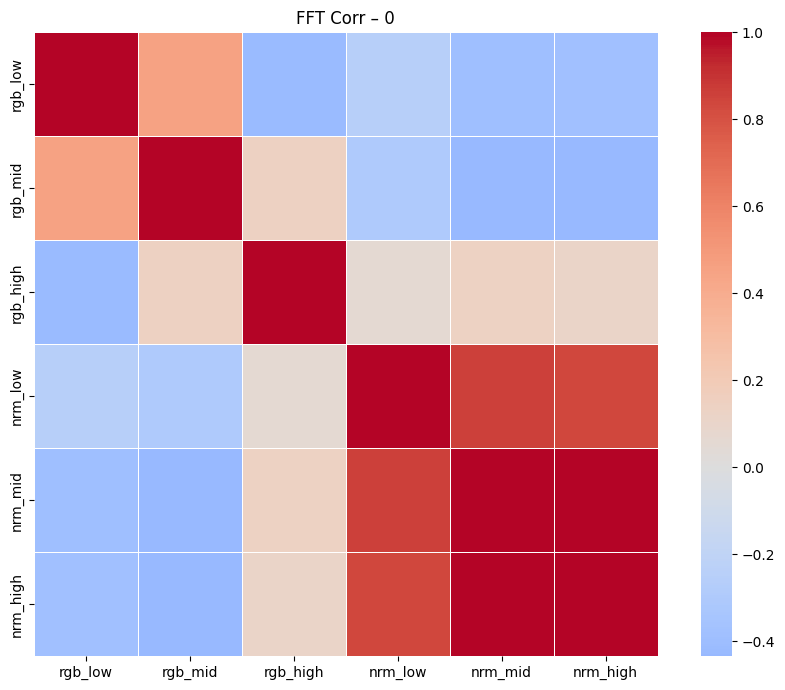

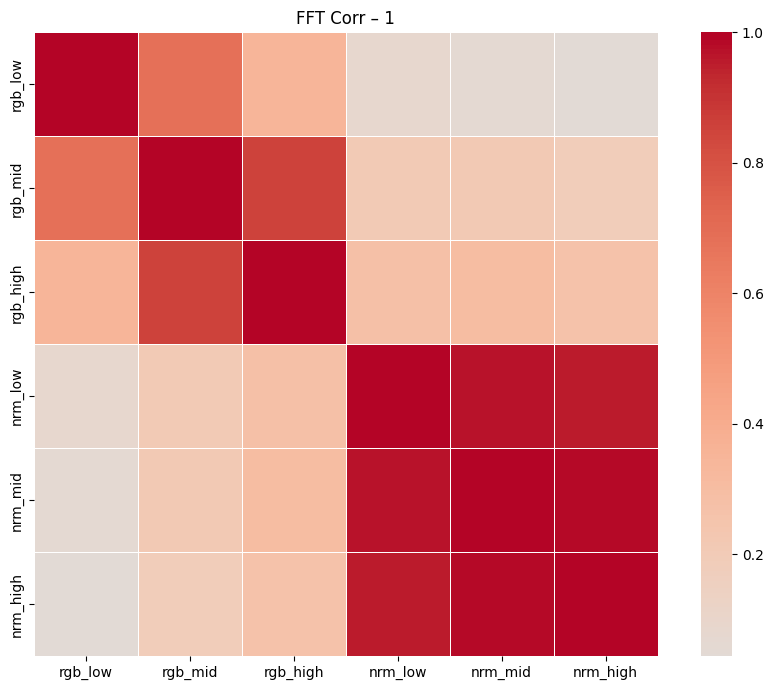

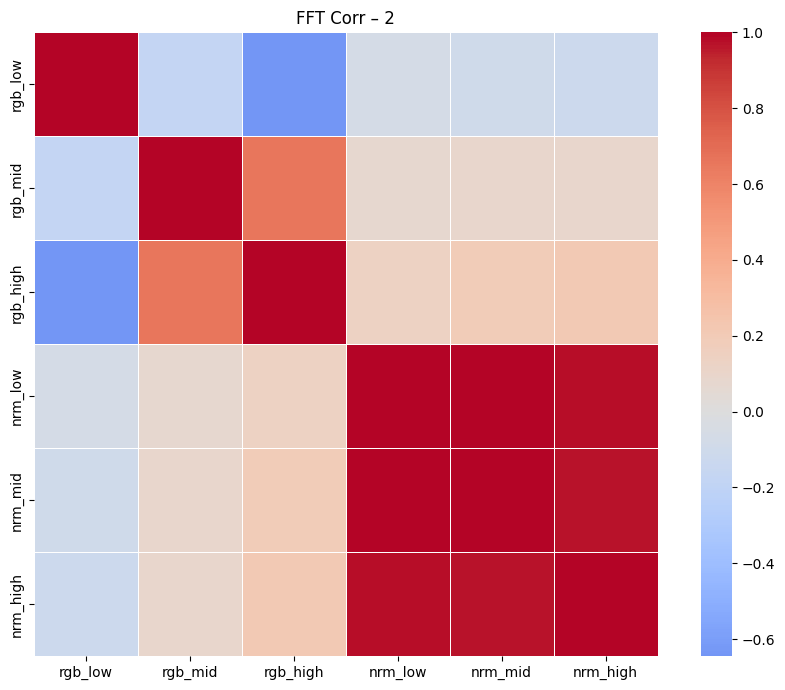

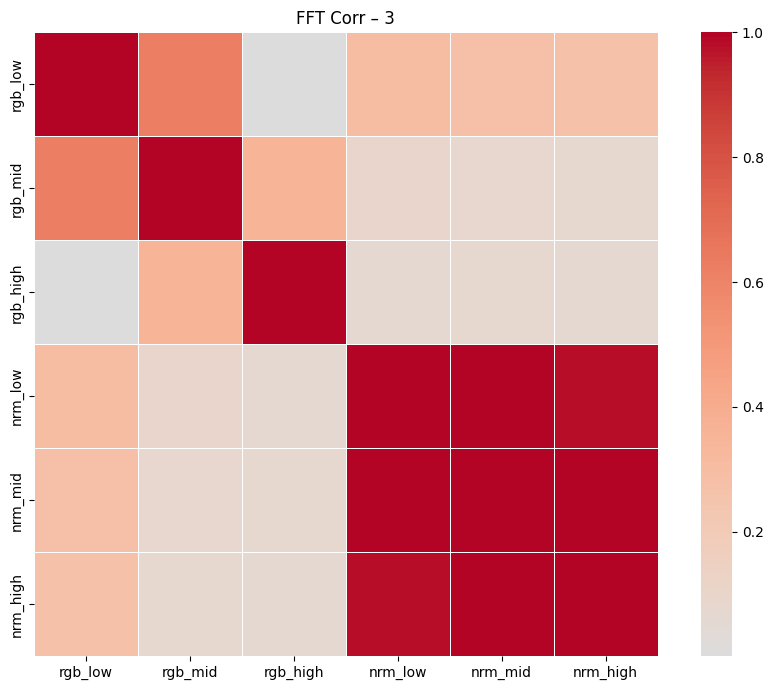

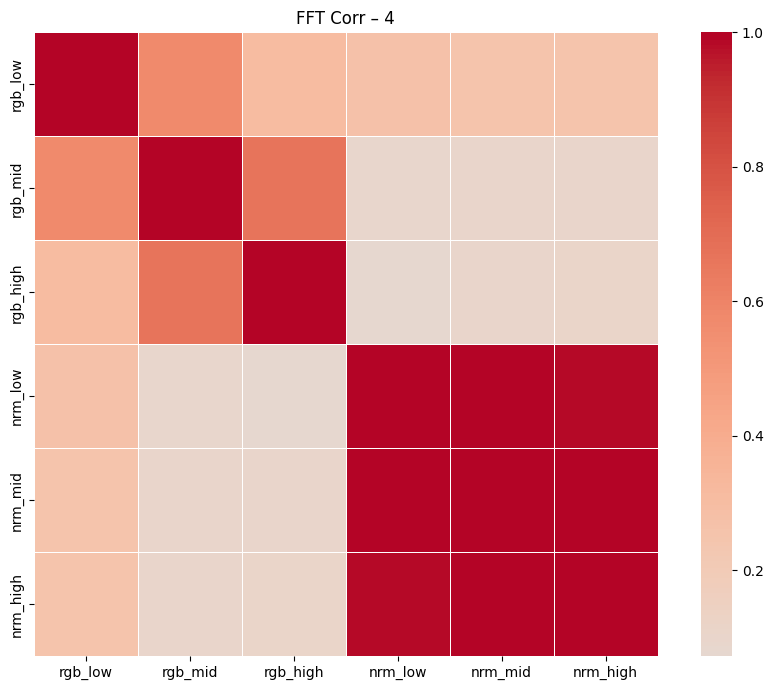

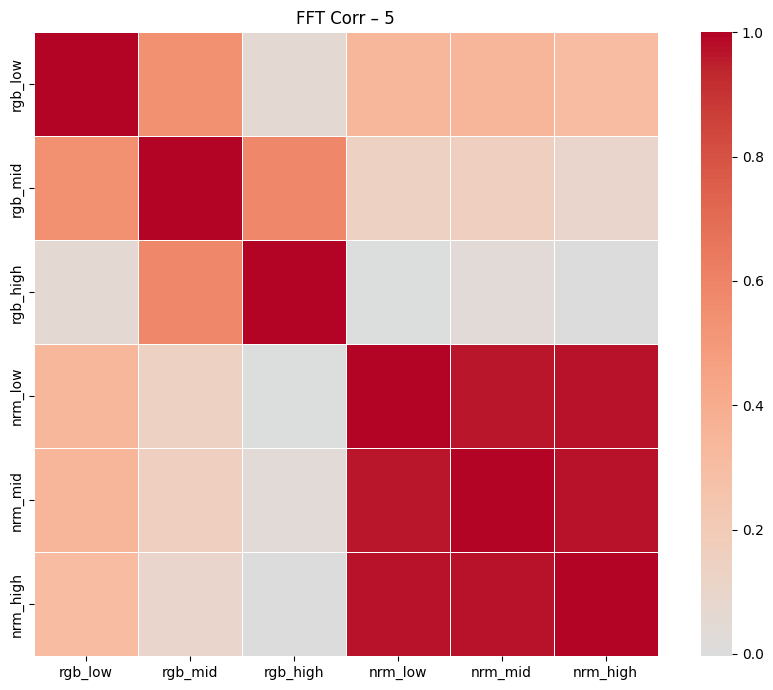

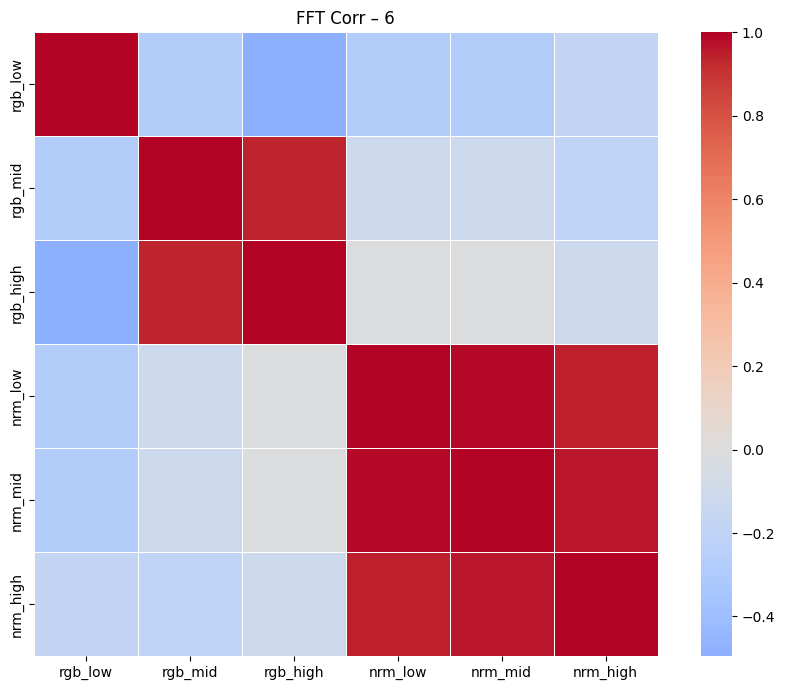

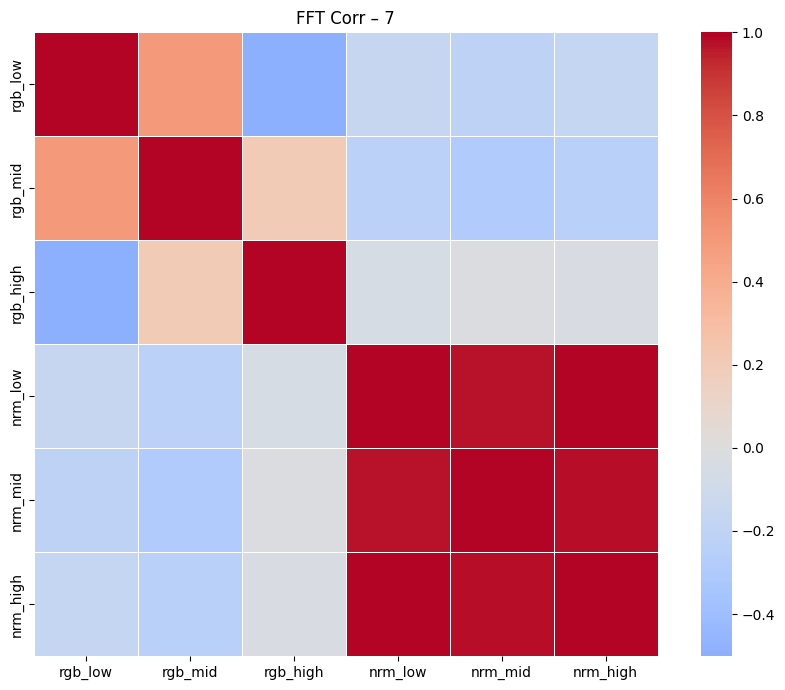

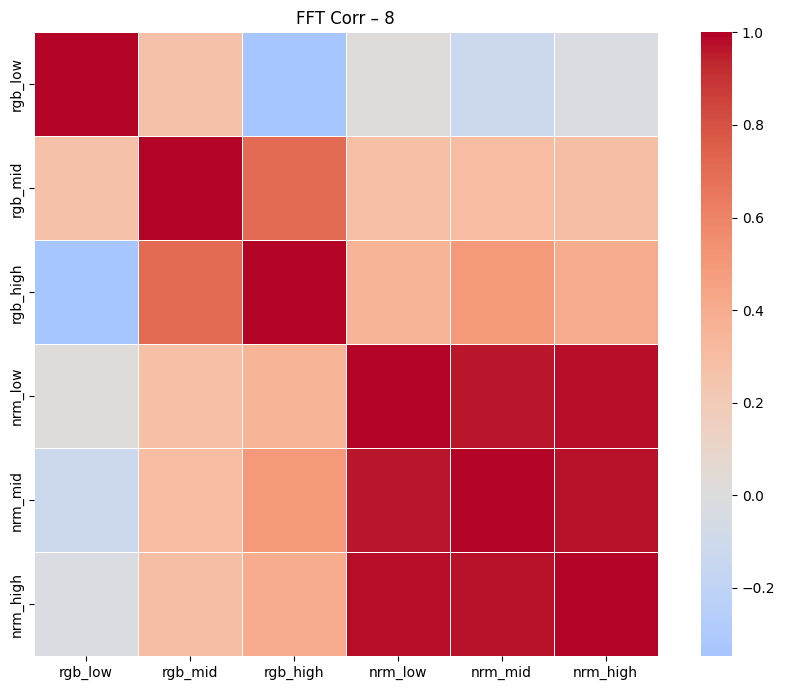

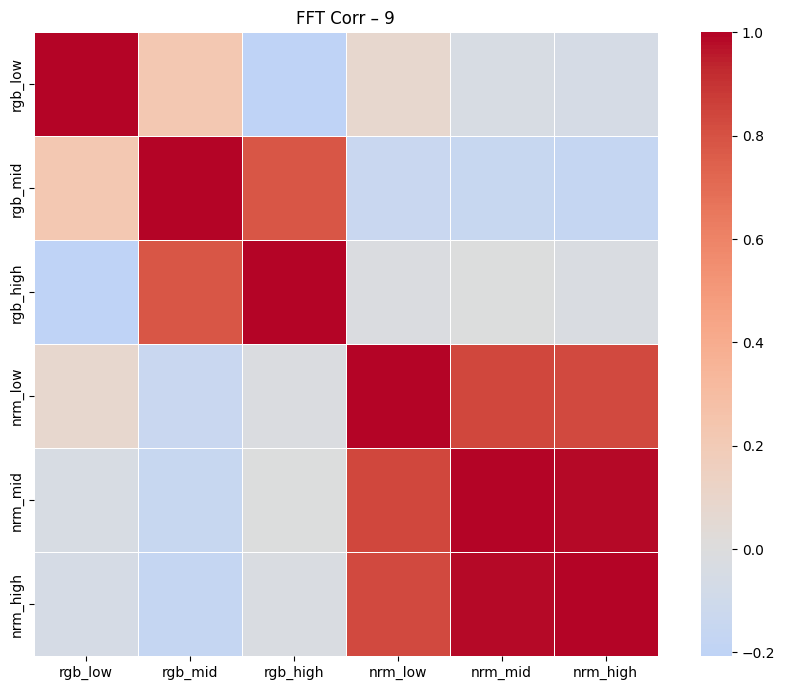

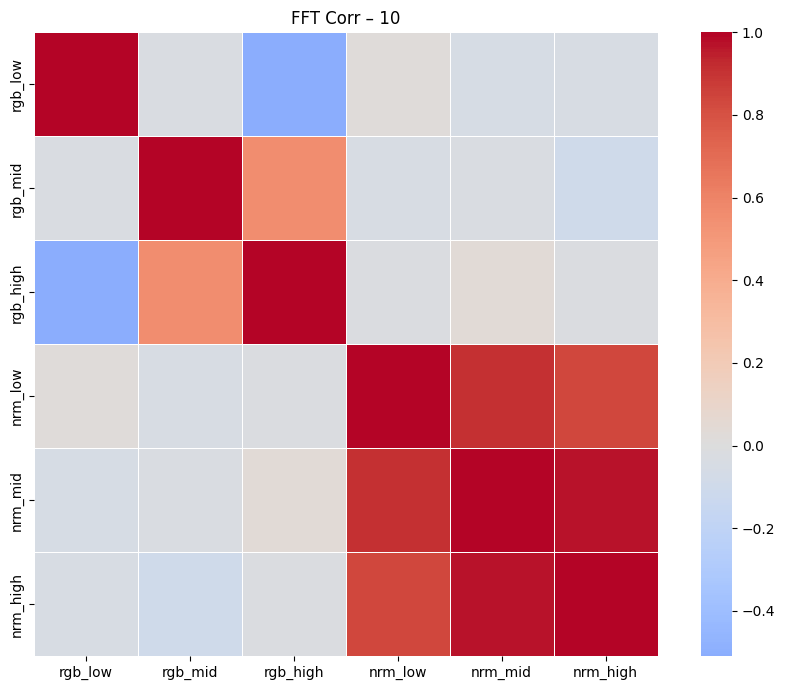

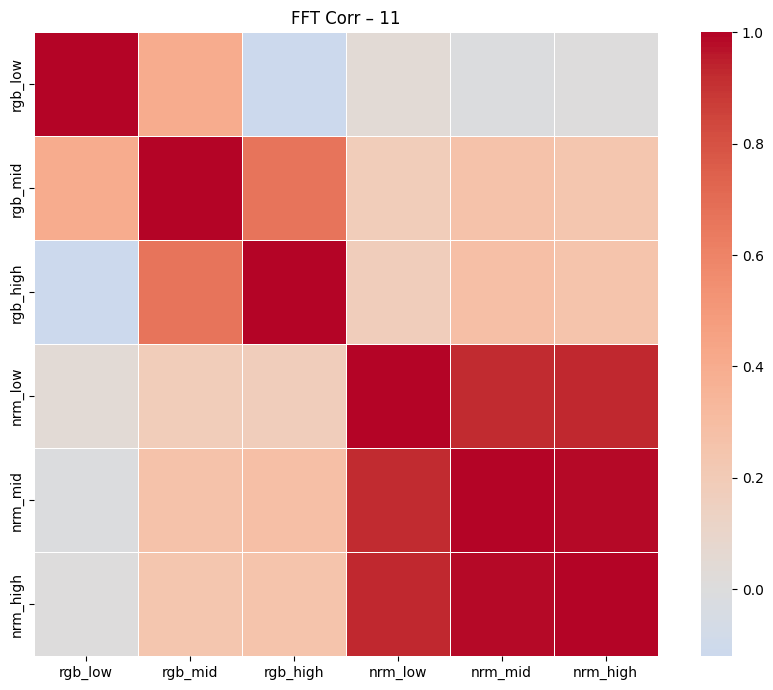

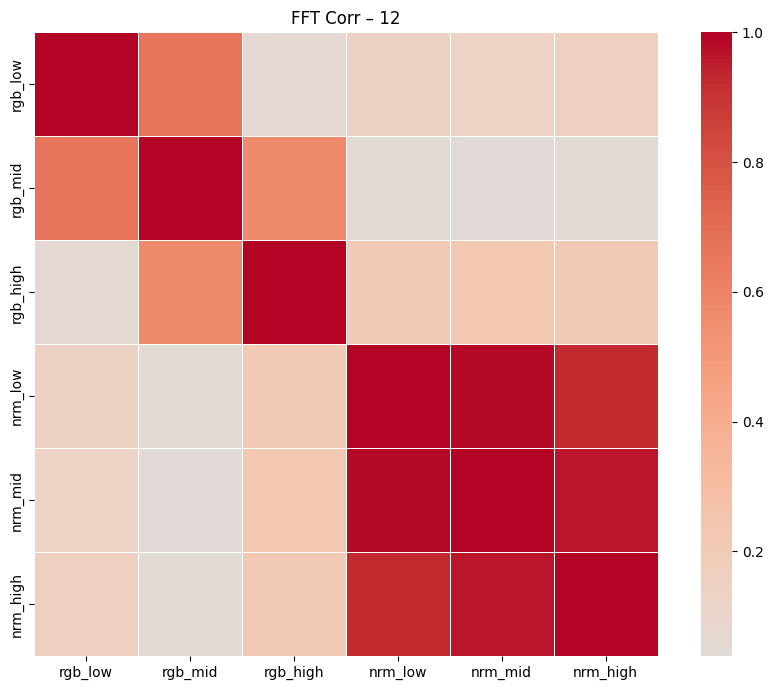

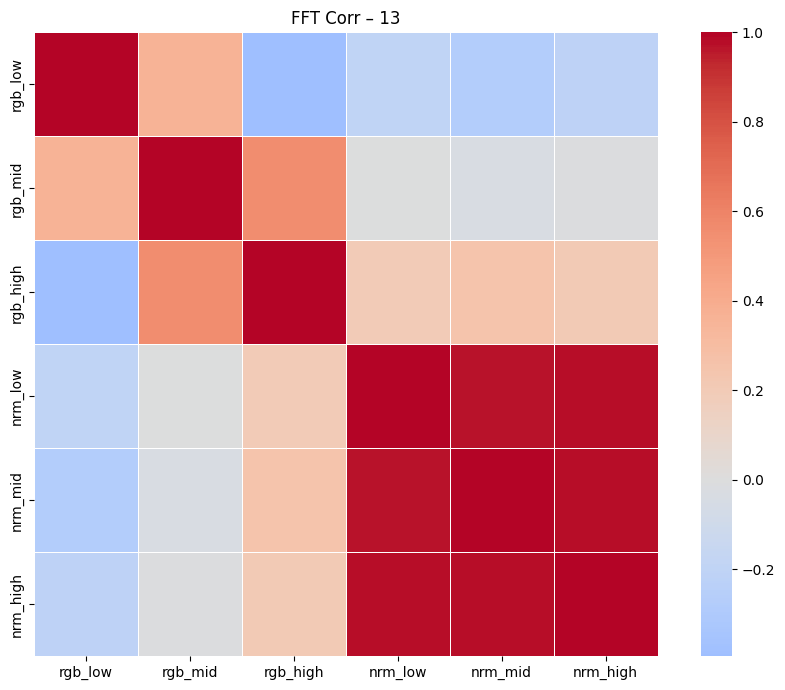

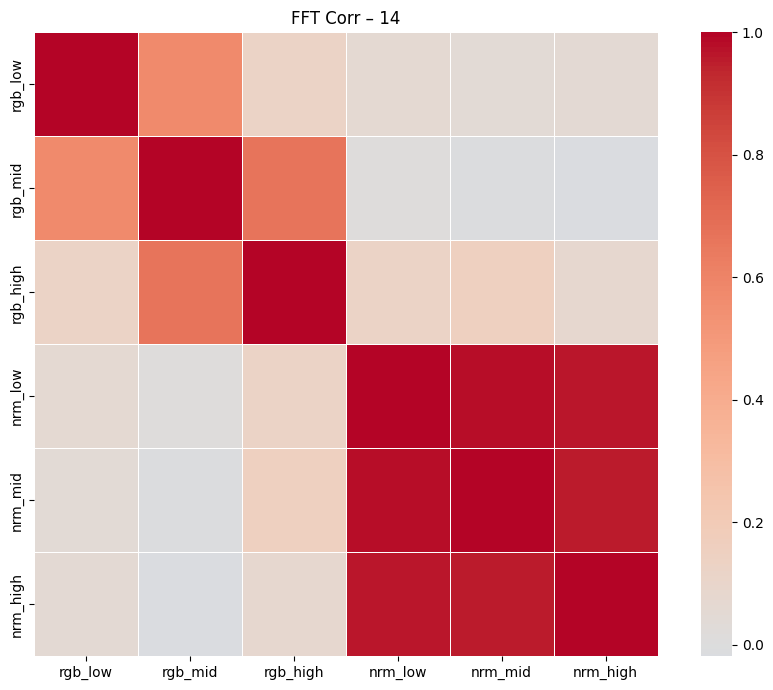

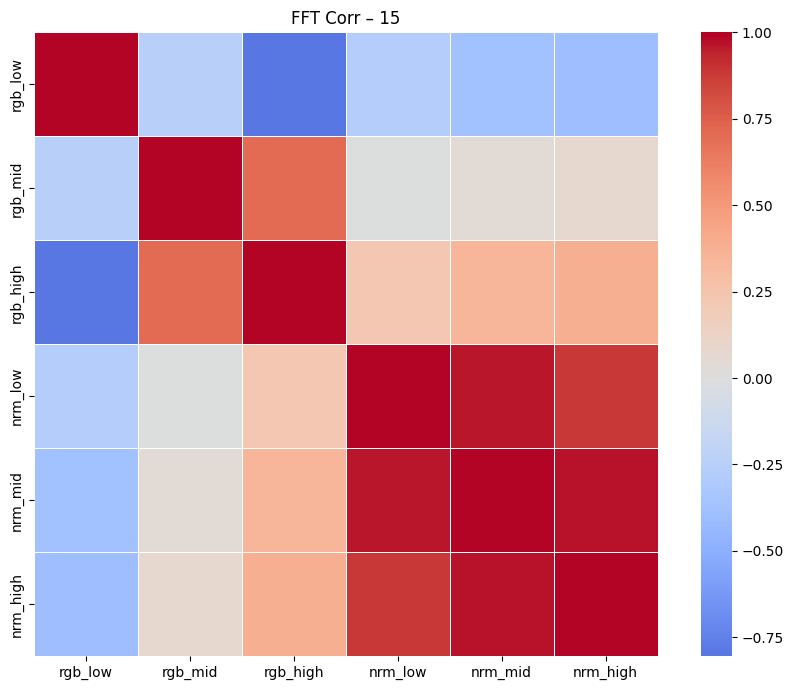

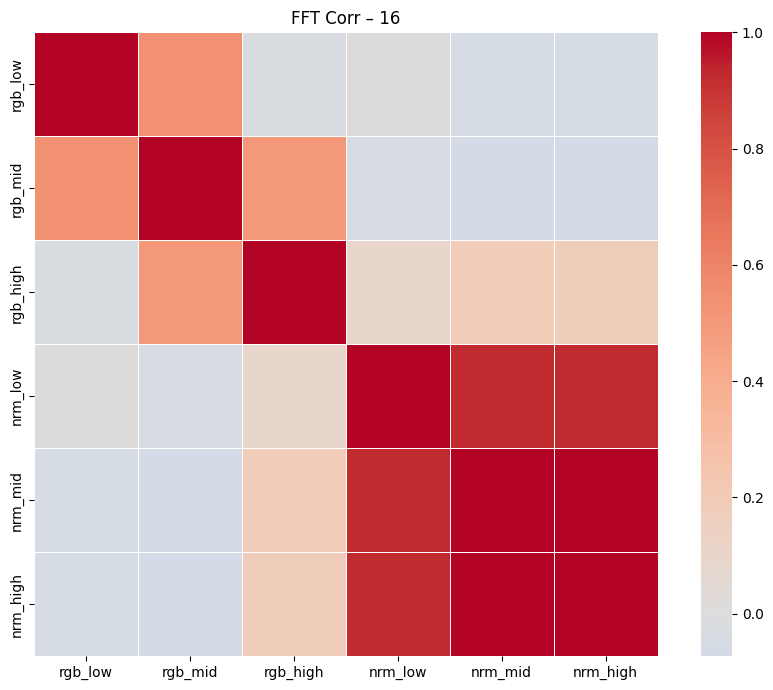

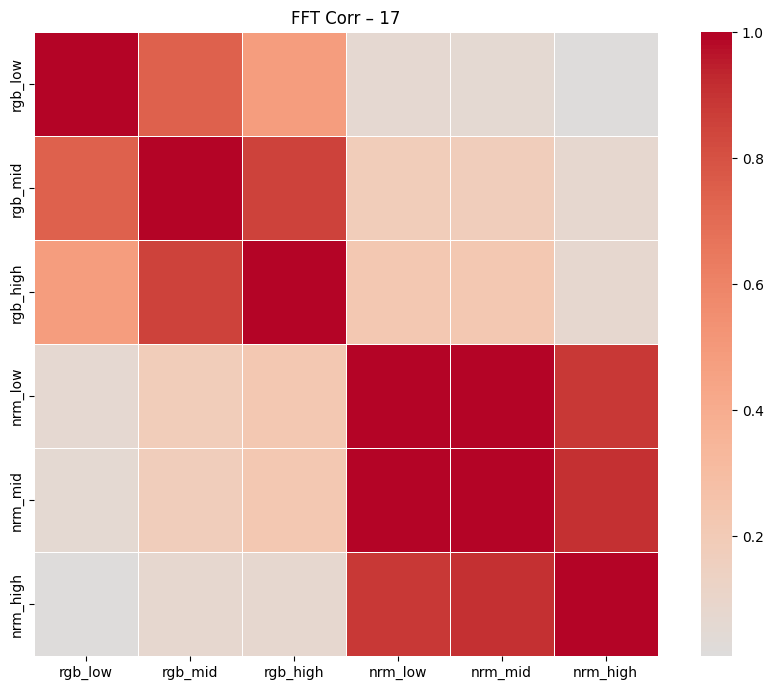

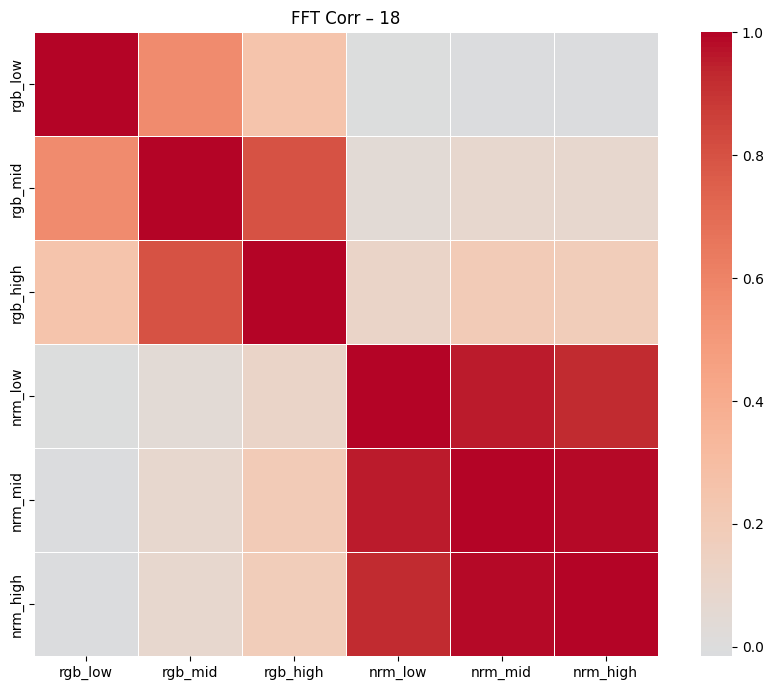

In [578]:
for cls, sub in df.groupby("class"):
    plot_feature_corr(sub.drop(columns=["class"]),
                      title=f"FFT Corr – {cls}")

In [579]:
import torch
import torch.nn as nn
from torchvision import models

In [580]:
class EarlyFusionNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)

        self.backbone.conv1 = nn.Conv2d(
            6, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        self.backbone.fc = nn.Linear(512, num_classes)

    def forward(self, rgb, normals):
        x = torch.cat([rgb, normals], dim=1)  
        return self.backbone(x)

In [581]:
class MidFusionNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.rgb_encoder = models.resnet18(weights="IMAGENET1K_V1")
        self.norm_encoder = models.resnet18(weights=None)

        # Remove classifiers
        self.rgb_encoder.fc = nn.Identity()
        self.norm_encoder.fc = nn.Identity()

        self.fusion = nn.Sequential(
            nn.Linear(512 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, rgb, normals):
        rgb_feat = self.rgb_encoder(rgb)        
        norm_feat = self.norm_encoder(normals)

        fused = torch.cat([rgb_feat, norm_feat], dim=1)
        return self.fusion(fused)


In [582]:
class LateFusionNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.rgb_net = models.resnet18(weights="IMAGENET1K_V1")
        self.norm_net = models.resnet18(weights=None)

        self.rgb_net.fc = nn.Linear(512, num_classes)
        self.norm_net.fc = nn.Linear(512, num_classes)

    def forward(self, rgb, normals):
        rgb_logits = self.rgb_net(rgb)
        norm_logits = self.norm_net(normals)

        # Simple averaging 
        return (rgb_logits + norm_logits) / 2


In [598]:
criterion = nn.CrossEntropyLoss(reduction="none")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.3, patience=3)


In [599]:
from collections import defaultdict

def evaluate_model(model, dataloader, criterion, device="cpu"):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    loss_per_class = defaultdict(list)
    batch_losses = []
    with torch.no_grad():
        for rgb, normals, labels in dataloader:
            rgb = rgb.to(device)
            normals = normals.to(device)
            labels = labels.to(device)

            logits = model(rgb, normals)  
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            # per-sample loss
            losses = criterion(logits, labels)  # shape: [B]
            batch_losses.append(losses.mean().item())

            for l, sample_loss in zip(labels.cpu(), losses.cpu()):
                loss_per_class[int(l)].append(sample_loss.item())

            all_preds.append(preds.cpu())
            # print(torch.bincount(torch.cat(all_preds)))
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())
    val_loss_epoch = float(np.mean(batch_losses))
    return (
        torch.cat(all_preds),
        torch.cat(all_labels),
        torch.cat(all_probs),
        np.array(val_loss_epoch),
        loss_per_class
    )

In [600]:
from collections import defaultdict

# Initialize variables for early stopping
best_val_loss = float("inf")
best_epoch = -1

# keeping track of validation loss COMPLETE ME
val_loss_history = []

# Training loop
def train_model(model, dataloader, criterion, optimizer, epochs, device="cpu"):
    training_losses=[]
    val_losses=[]
    for epoch in range(epochs):
        model.train()
        train_losses = []

        # TOOD: keep track of regression metrics
        for X_batch, d_batch, y_batch in dataloader:
            X_batch, d_batch, y_batch = X_batch.to(device), d_batch.to(device), y_batch.to(device) 
            
            optimizer.zero_grad() 
            outputs = model(X_batch, d_batch)
            loss = criterion(outputs, y_batch).mean()
            loss.backward()
            optimizer.step() 
            
            train_losses.append(loss.item())
            

        training_losses.append(np.mean(train_losses))    
        preds, labels, probs, val_loss_epoch, loss_per_class = evaluate_model(model, dataloader, criterion)  
        scheduler.step(val_loss_epoch) 
        val_losses.append(val_loss_epoch)
    return training_losses, val_losses



In [601]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

def analysis(train_loss, val_loss, loss_per_class, all_labels, all_preds, all_probs):
    
    for cls, losses in loss_per_class.items():
        print(f"Class {cls}: mean loss = {np.mean(losses):.4f}")
        
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    print("Overall accuracy:", accuracy_score(all_labels, all_preds))

    print(
        classification_report(
        all_labels,
        all_preds,
        labels=range(len(train_dataset.classes)),
        target_names=train_dataset.classes,
        zero_division=0
        )
    )

    num_classes = len(train_dataset.classes)

    y_true_bin = label_binarize(all_labels.numpy(), classes=range(num_classes))
    y_scores = all_probs.numpy()

    plt.figure(figsize=(8,6))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{train_dataset.classes[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (One-vs-Rest)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training Curve")
    plt.show()

In [585]:
print(len(train_dataset.classes))
print(range(len(train_dataset.classes)))

19
range(0, 19)


/var/folders/sj/ndc3yh8s1yxc4npz15m9pyrh0000gn/T/ipykernel_38874/1827596575.py:46: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normals = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + 1e-8) # normalize
/Users/sutku/Scripts/ML/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sutku/Scripts/ML/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Unique train labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18])
Num classes: 19
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18])
19
Class 2: mean loss = 4.9508
Class 13: mean loss = 3.7025
Class 18: mean loss = 3.2471
Class 5: mean loss = 5.3642
Class 4: mean loss = 1.1700
Class 0: mean loss = 5.1764
Class 9: mean loss = 0.8086
Class 1: mean loss = 4.1708
Class 6: mean loss = 0.8420
Class 7: mean loss = 2.2013
Class 12: mean loss = 6.3628
Class 10: mean loss = 2.3864
Class 11: mean loss = 2.7948
Class 8: mean loss = 7.0747
Class 16: mean loss = 2.8082
Class 17: mean loss = 1.8667
Class 14: mean loss = 1.6085
Class 3: mean loss = 3.7704
Class 15: mean loss = 0.4487


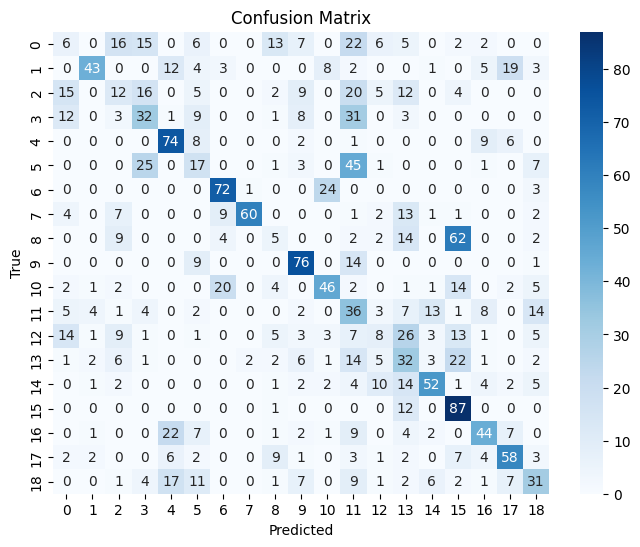

Overall accuracy: 0.4163157894736842
                            precision    recall  f1-score   support

                   Asphalt       0.10      0.06      0.07       100
                     Brick       0.78      0.43      0.55       100
         Cement - Granular       0.18      0.12      0.14       100
           Cement - Smooth       0.33      0.32      0.32       100
  Concrete - Cast_in_Place       0.56      0.74      0.64       100
        Concrete - Precast       0.21      0.17      0.19       100
                   Foliage       0.67      0.72      0.69       100
                     Grass       0.95      0.60      0.74       100
                    Gravel       0.11      0.05      0.07       100
                    Marble       0.59      0.76      0.67       100
            Metal - Grills       0.54      0.46      0.50       100
                    Paving       0.16      0.36      0.22       100
            Soil - Compact       0.18      0.08      0.11       100
Soil - Dir

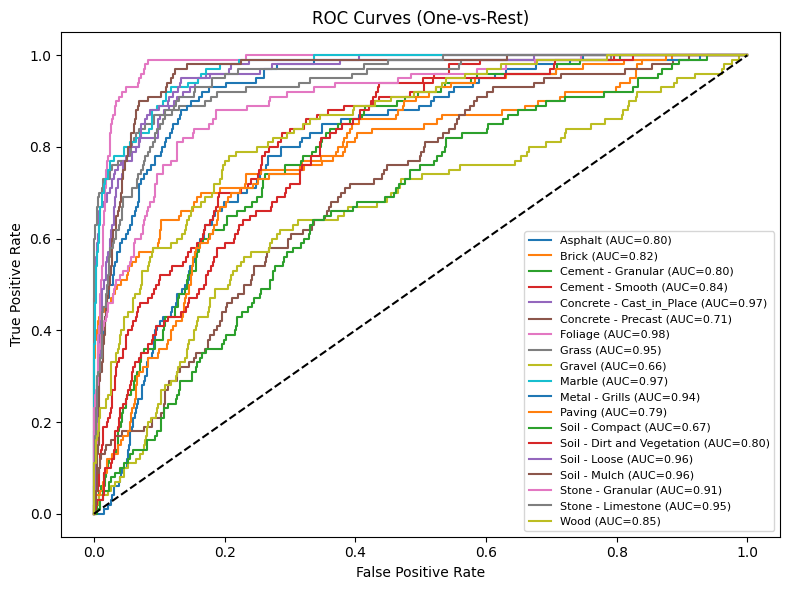

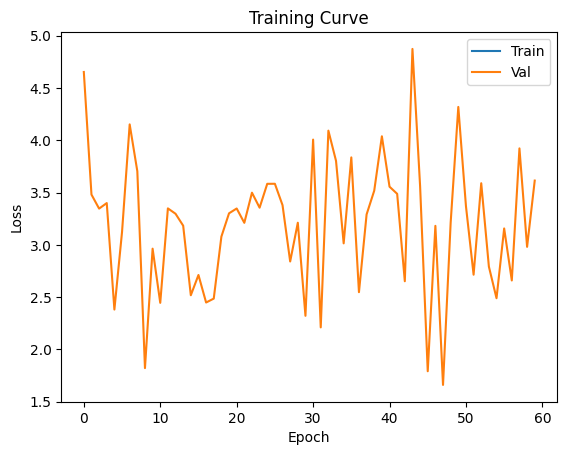

In [590]:
early_model = EarlyFusionNet(len(train_dataset.classes))
optimizer = torch.optim.Adam(early_model.parameters(), lr=0.0001) # lr and wd are hyperparamters
criterion = nn.CrossEntropyLoss(reduction="none")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.3, patience=3)

early_train_loss = train_model(early_model,train_loader,criterion,optimizer, 20)
early_preds, early_labels, early_probs, early_l_val, early_l_class = evaluate_model(early_model,test_loader,criterion)
print("Unique train labels:", torch.unique(early_labels))
print("Num classes:", len(train_dataset.classes))
print(torch.unique(early_labels))
print(len(torch.unique(early_labels)))

analysis(early_train_loss, early_l_val, early_l_class, early_labels, early_preds, early_probs)

In [587]:
print(len(early_l_val))

60


/var/folders/sj/ndc3yh8s1yxc4npz15m9pyrh0000gn/T/ipykernel_38874/1827596575.py:46: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normals = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + 1e-8) # normalize


Class 7: mean loss = 0.5216
Class 3: mean loss = 1.3681
Class 1: mean loss = 1.3766
Class 11: mean loss = 2.3276
Class 18: mean loss = 0.4462
Class 17: mean loss = 0.5602
Class 16: mean loss = 0.0709
Class 8: mean loss = 1.6924
Class 15: mean loss = 1.3859
Class 9: mean loss = 0.1123
Class 0: mean loss = 3.3560
Class 10: mean loss = 0.9262
Class 5: mean loss = 2.9823
Class 13: mean loss = 1.7135
Class 14: mean loss = 0.3082
Class 2: mean loss = 1.9342
Class 6: mean loss = 1.1468
Class 12: mean loss = 2.5200
Class 4: mean loss = 0.3520


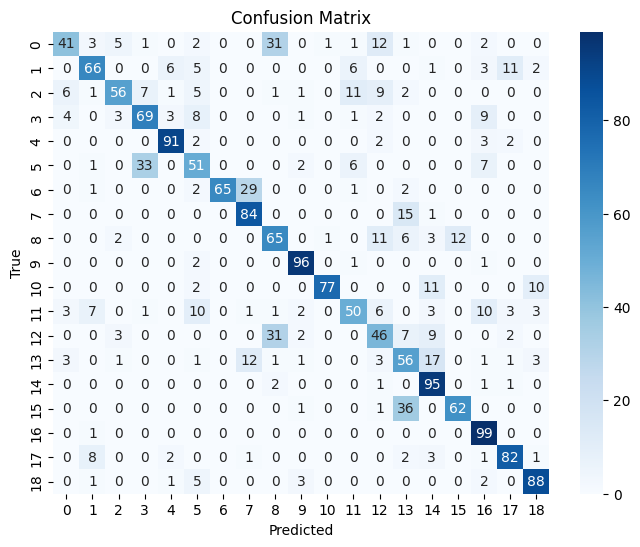

Overall accuracy: 0.7047368421052631
                            precision    recall  f1-score   support

                   Asphalt       0.72      0.41      0.52       100
                     Brick       0.74      0.66      0.70       100
         Cement - Granular       0.80      0.56      0.66       100
           Cement - Smooth       0.62      0.69      0.65       100
  Concrete - Cast_in_Place       0.88      0.91      0.89       100
        Concrete - Precast       0.54      0.51      0.52       100
                   Foliage       1.00      0.65      0.79       100
                     Grass       0.66      0.84      0.74       100
                    Gravel       0.49      0.65      0.56       100
                    Marble       0.88      0.96      0.92       100
            Metal - Grills       0.97      0.77      0.86       100
                    Paving       0.65      0.50      0.56       100
            Soil - Compact       0.49      0.46      0.48       100
Soil - Dir

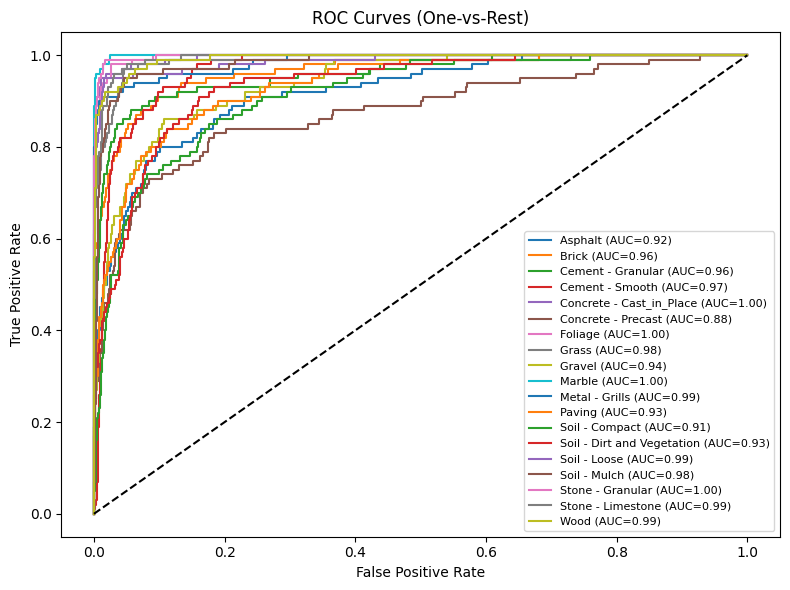

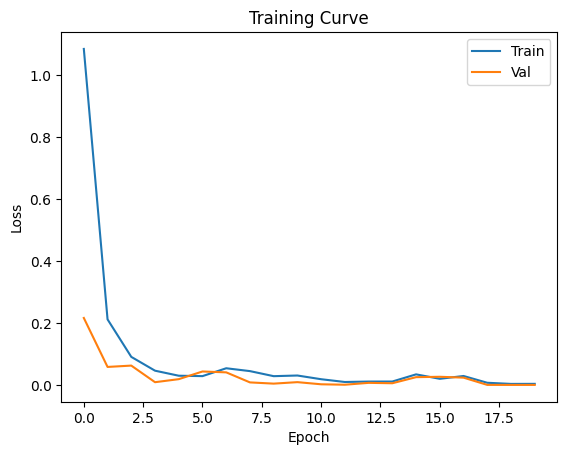

In [602]:
mid_model = MidFusionNet(19)
optimizer = torch.optim.Adam(mid_model.parameters(), lr=0.0001, weight_decay=1e-4) # lr and wd are hyperparamters
criterion = nn.CrossEntropyLoss(reduction="none")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.3, patience=4)

mid_train_loss, val_loss_epochs = train_model(mid_model,train_loader,criterion,optimizer, 20)
mid_preds, mid_labels, mid_probs, mid_l_val, mid_l_class = evaluate_model(mid_model,test_loader,criterion)

analysis(mid_train_loss, val_loss_epochs, mid_l_class, mid_labels, mid_preds, mid_probs)

/var/folders/sj/ndc3yh8s1yxc4npz15m9pyrh0000gn/T/ipykernel_38874/1827596575.py:46: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normals = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + 1e-8) # normalize
/Users/sutku/Scripts/ML/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sutku/Scripts/ML/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Class 14: mean loss = 0.2479
Class 4: mean loss = 1.0517
Class 17: mean loss = 1.0151
Class 10: mean loss = 0.9188
Class 5: mean loss = 0.9623
Class 12: mean loss = 1.7108
Class 11: mean loss = 3.9886
Class 7: mean loss = 0.5102
Class 16: mean loss = 0.0484
Class 2: mean loss = 3.2263
Class 18: mean loss = 1.3312
Class 8: mean loss = 1.6330
Class 1: mean loss = 3.6723
Class 9: mean loss = 3.4626
Class 13: mean loss = 3.5220
Class 0: mean loss = 4.8171
Class 3: mean loss = 7.4502
Class 15: mean loss = 0.8296
Class 6: mean loss = 1.6970


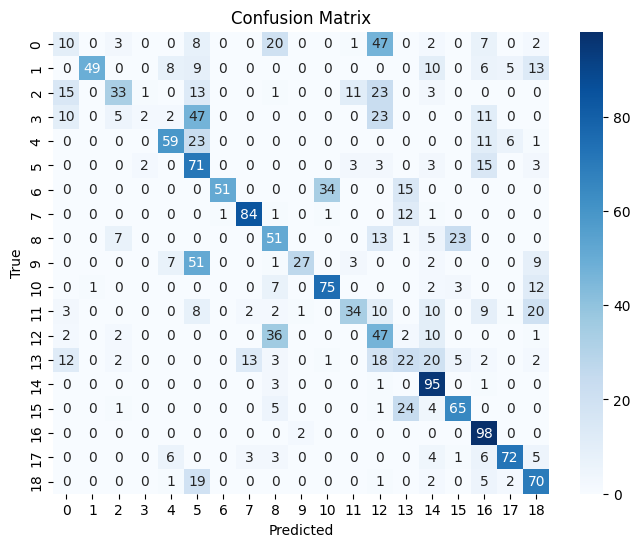

Overall accuracy: 0.5342105263157895
                            precision    recall  f1-score   support

                   Asphalt       0.19      0.10      0.13       100
                     Brick       0.98      0.49      0.65       100
         Cement - Granular       0.62      0.33      0.43       100
           Cement - Smooth       0.40      0.02      0.04       100
  Concrete - Cast_in_Place       0.71      0.59      0.64       100
        Concrete - Precast       0.29      0.71      0.41       100
                   Foliage       0.98      0.51      0.67       100
                     Grass       0.82      0.84      0.83       100
                    Gravel       0.38      0.51      0.44       100
                    Marble       0.90      0.27      0.42       100
            Metal - Grills       0.68      0.75      0.71       100
                    Paving       0.65      0.34      0.45       100
            Soil - Compact       0.25      0.47      0.33       100
Soil - Dir

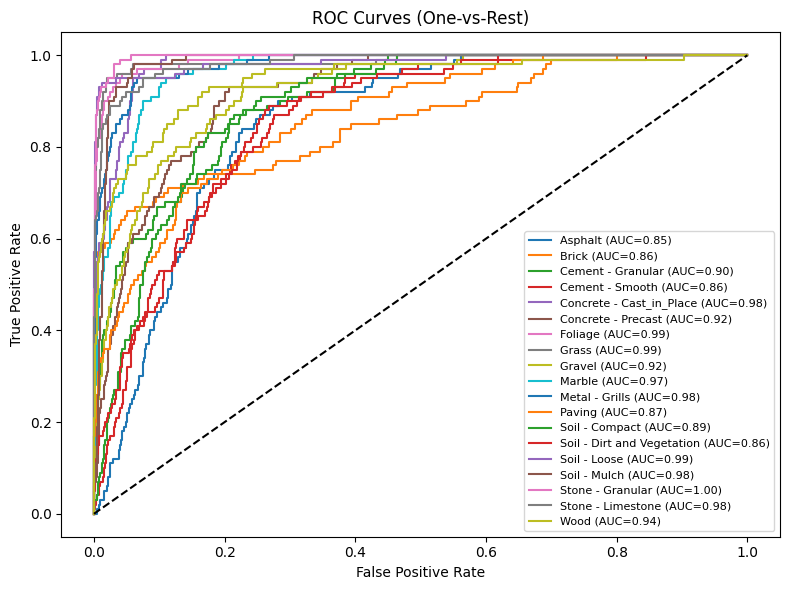

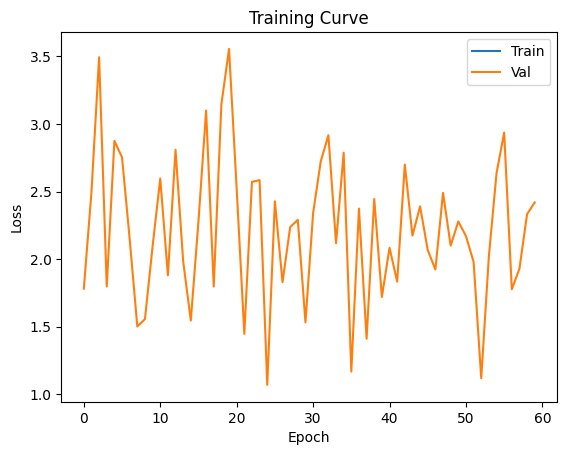

In [589]:
late_model = LateFusionNet(19)
optimizer = torch.optim.Adam(late_model.parameters(), lr=0.001, weight_decay=1e-4) # lr and wd are hyperparamters
criterion = nn.CrossEntropyLoss(reduction="none")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.3, patience=4)

late_train_loss = train_model(late_model,train_loader,criterion,optimizer, 20)
late_preds, late_labels, late_probs, late_l_val, late_l_class = evaluate_model(late_model,test_loader,criterion)

analysis(late_train_loss, late_l_val, late_l_class, late_labels, late_preds, late_probs)